In [1]:
import pandas


Loading 2022 from D:\XAI\pouya\Master thesis\data\stackoverflow2022.csv ...
  -> 36217 rows after preprocessing
Loading 2023 from D:\XAI\pouya\Master thesis\data\stackoverflow2023.csv ...
  -> 46200 rows after preprocessing
Loading 2024 from D:\XAI\pouya\Master thesis\data\stackoverflow2024.csv ...
  -> 22491 rows after preprocessing
STEP 1: Aggregated Query Sequence Visualization

Year 2022
  25-34 sequence: {'0-2': np.float64(135155.51), '3-5': np.float64(131692.26), '6-10': np.float64(173414.23), '10-20': np.float64(205396.89)}
  35-44 sequence: {'0-2': np.float64(123917.46), '3-5': np.float64(194520.56), '6-10': np.float64(212527.1), '10-20': np.float64(197010.15)}


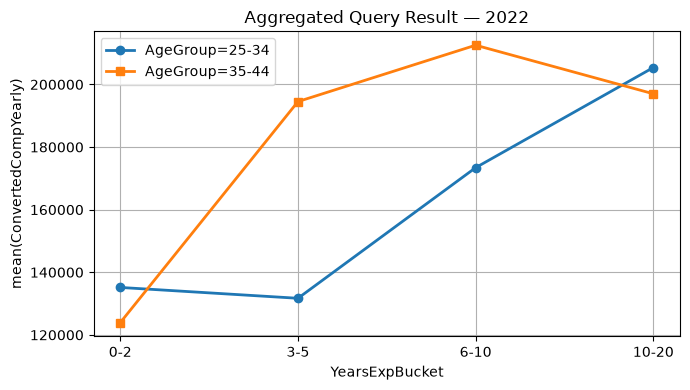


Year 2023
  25-34 sequence: {'0-2': np.float64(54942.7), '3-5': np.float64(78460.65), '6-10': np.float64(101225.97), '10-20': np.float64(123335.34)}
  35-44 sequence: {'0-2': np.float64(61915.33), '3-5': np.float64(82041.6), '6-10': np.float64(103612.35), '10-20': np.float64(117834.41)}


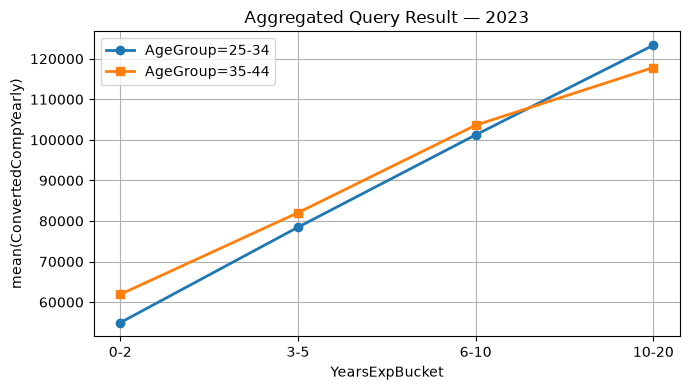


Year 2024
  25-34 sequence: {'0-2': np.float64(48420.21), '3-5': np.float64(65206.52), '6-10': np.float64(88695.91), '10-20': np.float64(113999.79)}
  35-44 sequence: {'0-2': np.float64(45925.06), '3-5': np.float64(72597.31), '6-10': np.float64(89861.28), '10-20': np.float64(114230.54)}


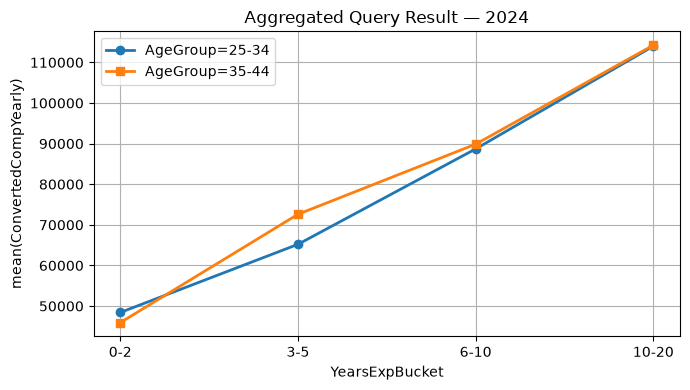

STEP 2: Detecting Year(s) With Notable Sequence Difference

Per-year divergence summary:
 year  raw_distance  relative_distance    zscore  flagged
 2022  75324.914730           0.215581  1.413597     True
 2023   9868.935528           0.052821 -0.670636    False
 2024   7890.558940           0.047173 -0.742961    False

Notable difference detected in year(s): [2022]


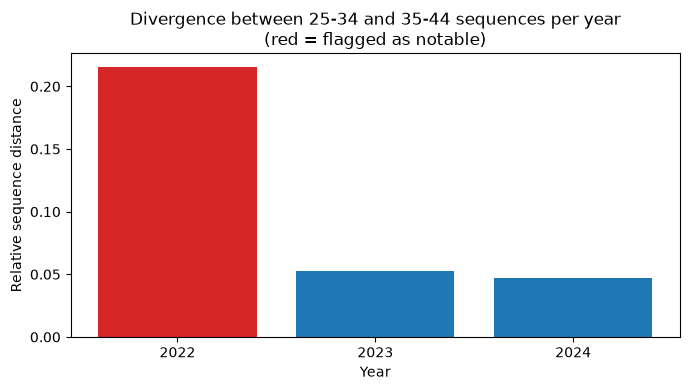

STEP 3: SDEcho Explanation for Year 2022
Comparing AgeGroup=25-34 (n=18146) vs 35-44 (n=9548)

Original sequence distance (before explanation): 75324.91

Top 10 explanatory predicates (lower gamma = stronger explanation; gamma near 1.0 = weak):

Rank 1 [STRONG]
  Predicate      : {'Country': 'United States of America'}
  Gamma          : 0.5813
  Distance before -> after : 75324.91 -> 30113.74 (60.0% reduction when removed)
  Support (n1, n2): (3497, 2496)
--------------------------------------------------
Rank 2 [MODERATE]
  Predicate      : {'EdLevel': 'Other doctoral degree (Ph.D., Ed.D., etc.)', 'Country': 'United States of America'}
  Gamma          : 0.7985
  Distance before -> after : 75324.91 -> 59018.20 (21.6% reduction when removed)
  Support (n1, n2): (109, 125)
--------------------------------------------------
Rank 3 [MODERATE]
  Predicate      : {'EdLevel': 'Some college/university study without earning a degree', 'Country': 'United States of America'}
  Gamma          : 

In [7]:
"""
explanation_pipeline.py

Three-step pipeline:
  Step 1: Visualize the aggregated sequences for two subgroups, per year.
  Step 2: Loop over years, compute a normalized divergence score between the
          two sequences, and flag year(s) with a notable difference.
  Step 3: For flagged year(s) only, run SDEcho (brute-force) to explain WHY
          the two sequences differ, using predicates as explanations.

No drift-detection, causal analysis, or other new methodology is included —
this only implements the three steps as specified.
"""

import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# ============================================================
# CONFIG — edit this block to point at your own data/columns
# ============================================================

CONFIG = {
    # --- data ---
    "csv_paths": {
        2022: r"D:\XAI\pouya\Master thesis\data\stackoverflow2022.csv",
        2023: r"D:\XAI\pouya\Master thesis\data\stackoverflow2023.csv",
        2024: r"D:\XAI\pouya\Master thesis\data\stackoverflow2024.csv",
    },

    # --- the two sequences being compared ---
    "subgroup_col": "AgeGroup",       # column that defines the two groups
    "subgroup_val1": "25-34",
    "subgroup_val2": "35-44",

    # --- sequence definition (x-axis of the aggregated sequence) ---
    "group_col": "YearsExpBucket",
    "measure_col": "ConvertedCompYearly",
    "agg_func": "mean",

    # --- SDEcho candidate attributes (used only in Step 3) ---
    "candidate_attrs": ["EdLevel", "RemoteWork", "Country"],
    "max_order": 2,
    "k": 10,
    "max_values_per_attr": 10,

    # --- Step 2: how to flag a "notable" year ---
    # method: "zscore" (relative to other years) or "threshold" (absolute cutoff)
    "detection_method": "zscore",
    "zscore_threshold": 1.0,     # flag years with z-score >= this
    "absolute_threshold": None,  # only used if detection_method == "threshold"

    # --- Step 3: minimum rows required for a predicate to be reported ---
    "min_support": 20,
}


# ============================================================
# Data loading / preprocessing (modular — adjust for your own data)
# ============================================================

def load_and_preprocess_year(path, config):
    """
    Load one year's CSV and derive the columns needed for the pipeline
    (YearsExpBucket, AgeGroup, RemoteWork cleanup).

    Swap this function's body if your own data already has these columns,
    or if your bucketing/cleanup rules differ.
    """
    df = pd.read_csv(path)

    if "YearsCodePro" in df.columns:
        df["YearsExpBucket"] = pd.cut(
            pd.to_numeric(df["YearsCodePro"], errors="coerce"),
            bins=[0, 2, 5, 10, 20, 100],
            labels=["0-2", "3-5", "6-10", "10-20", "20+"],
        )

    if "Age" in df.columns:
        df["AgeGroup"] = df["Age"].str.extract(r"(\d+-\d+)")

    if "RemoteWork" in df.columns:
        df["RemoteWork"] = (
            df["RemoteWork"]
            .fillna("Unknown")
            .replace({"Hybrid (some remote, some in-person)": "Hybrid"})
        )

    required = [config["group_col"], config["subgroup_col"], config["measure_col"]]
    df = df.dropna(subset=[c for c in required if c in df.columns])
    return df


def load_all_years(config):
    """Returns dict[year -> preprocessed DataFrame]."""
    data_by_year = {}
    for year, path in config["csv_paths"].items():
        print(f"Loading {year} from {path} ...")
        data_by_year[year] = load_and_preprocess_year(path, config)
        print(f"  -> {len(data_by_year[year])} rows after preprocessing")
    return data_by_year


# ============================================================
# SDEcho core (brute-force, unmodified from prior implementation)
# ============================================================

def _aggregate_sequence(df, group_col, measure_col, agg_func, index):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        s = df.groupby(group_col)[measure_col].agg(agg_func)
    s = s.reindex(index)
    return s.fillna(0).to_numpy(dtype=float)


def _dist(v1, v2):
    return float(np.sqrt(np.sum((v1 - v2) ** 2)))


def _enumerate_predicates(df1, df2, candidate_attrs, max_order, max_values_per_attr=None):
    value_map = {}
    for a in candidate_attrs:
        combined = pd.concat([df1[a], df2[a]]).dropna()
        if max_values_per_attr is not None:
            top_vals = combined.value_counts().nlargest(max_values_per_attr).index
            value_map[a] = list(top_vals)
        else:
            value_map[a] = list(combined.unique())

    predicates = []
    for order in range(1, max_order + 1):
        for attrs in itertools.combinations(candidate_attrs, order):
            value_lists = [value_map[a] for a in attrs]
            for combo in itertools.product(*value_lists):
                predicates.append(dict(zip(attrs, combo)))
    return predicates


def _predicate_mask(df, predicate):
    mask = pd.Series(True, index=df.index)
    for attr, val in predicate.items():
        mask &= (df[attr] == val)
    return mask


def compute_gamma(df1, df2, group_col, measure_col, candidate_attrs,
                   agg_func="sum", max_order=2, k=10, max_values_per_attr=None,
                   min_support=0):
    """
    SDEcho explanation measure (brute-force). Returns top-k predicates by
    ascending gamma (lower gamma = stronger explanation), filtered to
    predicates with at least `min_support` combined matching rows.
    """
        # Desired order of the experience buckets
    desired_order = ["0-2", "3-5", "6-10", "10-20"]

    present = (
        set(df1[group_col].dropna().astype(str).unique()) |
        set(df2[group_col].dropna().astype(str).unique())
    )

    index = [x for x in desired_order if x in present]

    s1 = _aggregate_sequence(df1, group_col, measure_col, agg_func, index)
    s2 = _aggregate_sequence(df2, group_col, measure_col, agg_func, index)
    d0 = _dist(s1, s2)
    if d0 == 0:
        raise ValueError("Original sequences are identical (dist=0); nothing to explain.")

    n1, n2 = len(df1), len(df2)
    predicates = _enumerate_predicates(df1, df2, candidate_attrs, max_order, max_values_per_attr)

    results = []
    for pred in predicates:
        mask1 = _predicate_mask(df1, pred)
        mask2 = _predicate_mask(df2, pred)
        size1, size2 = int(mask1.sum()), int(mask2.sum())
        if size1 + size2 < min_support:
            continue  # skip low-support predicates (e.g., single-row artifacts)
        if size1 == 0 and size2 == 0:
            continue

        rest1 = df1.loc[~mask1]
        rest2 = df2.loc[~mask2]
        s1_e = _aggregate_sequence(rest1, group_col, measure_col, agg_func, index)
        s2_e = _aggregate_sequence(rest2, group_col, measure_col, agg_func, index)
        dist_after = _dist(s1_e, s2_e)

        penalty = 1.0 + size1 / n1 + size2 / n2
        gamma = (dist_after / d0) * penalty

        results.append({
            "predicate": pred,
            "gamma": gamma,
            "dist_after": dist_after,
            "dist_before": d0,
            "penalty": penalty,
            "n1": size1,
            "n2": size2,
        })

    results.sort(key=lambda r: r["gamma"])
    return results[:k], d0


# ============================================================
# STEP 1: Visualize the aggregated sequences per year
# ============================================================

def get_sequences_for_year(df, config):
    """Returns (index, seq1, seq2) for the configured subgroup comparison."""
    g1 = df[df[config["subgroup_col"]] == config["subgroup_val1"]]
    g2 = df[df[config["subgroup_col"]] == config["subgroup_val2"]]

    # Desired order of the experience buckets
    desired_order = ["0-2", "3-5", "6-10", "10-20"]

    # Keep only buckets that actually exist in the data
    present = (
        set(g1[config["group_col"]].dropna().astype(str).unique()) |
        set(g2[config["group_col"]].dropna().astype(str).unique())
    )

    index = [x for x in desired_order if x in present]

    seq1 = _aggregate_sequence(
        g1,
        config["group_col"],
        config["measure_col"],
        config["agg_func"],
        index,
    )

    seq2 = _aggregate_sequence(
        g2,
        config["group_col"],
        config["measure_col"],
        config["agg_func"],
        index,
    )

    return index, seq1, seq2


def step1_visualize(data_by_year, config):
    print("=" * 60)
    print("STEP 1: Aggregated Query Sequence Visualization")
    print("=" * 60)

    for year, df in sorted(data_by_year.items()):
        index, seq1, seq2 = get_sequences_for_year(df, config)

        print(f"\nYear {year}")
        print(f"  {config['subgroup_val1']} sequence: "
              f"{dict(zip(index, np.round(seq1, 2)))}")
        print(f"  {config['subgroup_val2']} sequence: "
              f"{dict(zip(index, np.round(seq2, 2)))}")

        plt.figure(figsize=(7, 4))
        plt.plot(index, seq1, marker='o', linewidth=2,
                  label=f"{config['subgroup_col']}={config['subgroup_val1']}")
        plt.plot(index, seq2, marker='s', linewidth=2,
                  label=f"{config['subgroup_col']}={config['subgroup_val2']}")
        plt.xlabel(config["group_col"])
        plt.ylabel(f"{config['agg_func']}({config['measure_col']})")
        plt.title(f"Aggregated Query Result — {year}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# STEP 2: Loop over years, detect year(s) with notable difference
# ============================================================

def step2_detect_difference_years(data_by_year, config):
    print("=" * 60)
    print("STEP 2: Detecting Year(s) With Notable Sequence Difference")
    print("=" * 60)

    records = []
    for year, df in sorted(data_by_year.items()):
        index, seq1, seq2 = get_sequences_for_year(df, config)
        raw_dist = _dist(seq1, seq2)

        # Normalize so distance is comparable across years even if the
        # measure's overall scale shifts (e.g., compensation levels change).
        magnitude = (np.linalg.norm(seq1) + np.linalg.norm(seq2)) / 2
        rel_dist = raw_dist / magnitude if magnitude > 0 else np.nan

        records.append({"year": year, "raw_distance": raw_dist,
                         "relative_distance": rel_dist})

    diff_df = pd.DataFrame(records).sort_values("year").reset_index(drop=True)

    # Flag notable year(s)
    if config["detection_method"] == "zscore":
        mean_d = diff_df["relative_distance"].mean()
        std_d = diff_df["relative_distance"].std(ddof=0)
        if std_d == 0 or np.isnan(std_d):
            diff_df["zscore"] = 0.0
        else:
            diff_df["zscore"] = (diff_df["relative_distance"] - mean_d) / std_d
        diff_df["flagged"] = diff_df["zscore"] >= config["zscore_threshold"]
    else:  # "threshold"
        cutoff = config["absolute_threshold"]
        diff_df["flagged"] = diff_df["relative_distance"] >= cutoff

    print("\nPer-year divergence summary:")
    print(diff_df.to_string(index=False))

    flagged_years = diff_df.loc[diff_df["flagged"], "year"].tolist()
    if flagged_years:
        print(f"\nNotable difference detected in year(s): {flagged_years}")
    else:
        print("\nNo year exceeded the notability criterion; "
              "Step 3 will not run automatically.")

    # Visualize divergence across years
    plt.figure(figsize=(7, 4))
    colors = ["tab:red" if f else "tab:blue" for f in diff_df["flagged"]]
    plt.bar(diff_df["year"].astype(str), diff_df["relative_distance"], color=colors)
    plt.xlabel("Year")
    plt.ylabel("Relative sequence distance")
    plt.title(f"Divergence between {config['subgroup_val1']} and "
              f"{config['subgroup_val2']} sequences per year\n"
              f"(red = flagged as notable)")
    plt.tight_layout()
    plt.show()

    return diff_df, flagged_years


# ============================================================
# STEP 3: SDEcho explanation — only for flagged year(s)
# ============================================================

def step3_explain_year(df, year, config):
    print("=" * 60)
    print(f"STEP 3: SDEcho Explanation for Year {year}")
    print("=" * 60)

    g1 = df[df[config["subgroup_col"]] == config["subgroup_val1"]].copy()
    g2 = df[df[config["subgroup_col"]] == config["subgroup_val2"]].copy()

    print(f"Comparing {config['subgroup_col']}={config['subgroup_val1']} "
          f"(n={len(g1)}) vs {config['subgroup_val2']} (n={len(g2)})")

    top_results, d0 = compute_gamma(
        g1, g2,
        group_col=config["group_col"],
        measure_col=config["measure_col"],
        candidate_attrs=config["candidate_attrs"],
        agg_func=config["agg_func"],
        max_order=config["max_order"],
        k=config["k"],
        max_values_per_attr=config["max_values_per_attr"],
        min_support=config["min_support"],
    )

    print(f"\nOriginal sequence distance (before explanation): {d0:.2f}")

    if not top_results:
        print("No predicate met the minimum support threshold "
              f"({config['min_support']} rows) — no interpretable "
              "explanation could be produced for this year.")
        return top_results

    print(f"\nTop {len(top_results)} explanatory predicates "
          f"(lower gamma = stronger explanation; gamma near 1.0 = weak):\n")

    for i, r in enumerate(top_results, 1):
        reduction_pct = (1 - r["dist_after"] / r["dist_before"]) * 100
        strength = "STRONG" if r["gamma"] < 0.7 else (
            "WEAK" if r["gamma"] > 0.95 else "MODERATE")
        print(f"Rank {i} [{strength}]")
        print(f"  Predicate      : {r['predicate']}")
        print(f"  Gamma          : {r['gamma']:.4f}")
        print(f"  Distance before -> after : {r['dist_before']:.2f} -> {r['dist_after']:.2f} "
              f"({reduction_pct:.1f}% reduction when removed)")
        print(f"  Support (n1, n2): ({r['n1']}, {r['n2']})")
        print("-" * 50)

    return top_results


# ============================================================
# Orchestration
# ============================================================

def run_pipeline(config=CONFIG):
    data_by_year = load_all_years(config)

    # Step 1
    step1_visualize(data_by_year, config)

    # Step 2
    diff_df, flagged_years = step2_detect_difference_years(data_by_year, config)

    # Step 3 — only runs for flagged years
    all_explanations = {}
    for year in flagged_years:
        results = step3_explain_year(data_by_year[year], year, config)
        all_explanations[year] = results

    return data_by_year, diff_df, all_explanations


if __name__ == "__main__":
    data_by_year, diff_df, all_explanations = run_pipeline(CONFIG)